In [17]:
import stravalib
import os
import pandas as pd

client = stravalib.client.Client()
with open(os.path.expanduser('~/.strava_token'), 'r') as f:
    client.access_token = f.read().strip()
# client.access_token = os.environ['STRAVA_ACCESS_TOKEN']
# for segment in client.explore_segments(bounds=[37.812685, -122.532434, 37.865305, -122.477496], activity_type='riding'):
#     print(segment.distance)
#     break

def get_segment_df(segment_id):
    streams = client.get_segment_streams(
        segment_id,
        types=['distance', 'altitude'],
        resolution='high',      # options: 'low', 'medium', 'high'
        series_type='time',     # or 'distance'; use whichever axis you prefer
        # key_by_type=True        # makes the result a dict keyed by stream type
    )

    # 4. Extract the raw data arrays
    distance_data  = streams['distance'].data    # in meters
    elevation_data = streams['altitude'].data    # in meters ASL

    # 5. Build your DataFrame
    df = pd.DataFrame({
        'distance_m':  distance_data,
        'elevation_m': elevation_data
    })
    return df


In [36]:
import gpxpy
from gpxpy.geo import haversine_distance  # for horizontal distance

class Segment:
    def __init__(self, segment_id):
        self.segment_id = segment_id

    def get_elevation_df(self):
        return get_segment_df(self.segment_id)

def get_gpx_elevation_df(gpx_file_path):
    # parse the file
    with open(gpx_file_path, "r") as f:
        gpx = gpxpy.parse(f)

    elevation_data = []
    distance_data  = []
    cumdist = 0.0
    prev_pt = None

    # walk every point and accumulate
    for track in gpx.tracks:
        for segment in track.segments:
            for point in segment.points:
                if prev_pt is not None:
                    # add horizontal distance between prev_pt and point
                    cumdist += haversine_distance(
                        prev_pt.latitude, prev_pt.longitude,
                        point.latitude,    point.longitude
                    )
                elevation_data.append(point.elevation)
                distance_data .append(cumdist)
                prev_pt = point

    return pd.DataFrame({
        "distance_m": distance_data,
        "elevation_m": elevation_data
    })

class Route:
    def __init__(self, gpx_file_path):
        self.gpx_file_path = os.path.expanduser(gpx_file_path)

    def get_elevation_df(self):
        return get_gpx_elevation_df(self.gpx_file_path)

segments = {
    'uncanoonuc': Segment(669827),
    'uncanoonuc_only_mountain_rd': Segment(640028),
    'hawk_hill': Segment(229781),
    'kearsarge': Segment(5627579),
    'mt washington': Segment(3237),
    'kanc': Segment(695921),
    'prouty': Route('~/Downloads/prouty_gravel_2025.gpx'),
    'peg': Route('~/Downloads/Pavement_Ends_Short_Course.gpx'),
}
segment_dfs = {k: v.get_elevation_df() for k, v in segments.items()}

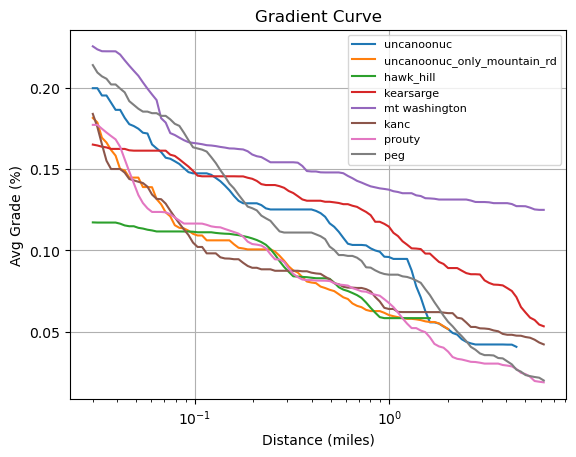

In [38]:
import numpy as np
from matplotlib import pyplot as plt

def get_gradient_curve(df):
    distances = np.linspace(0, df['distance_m'].max(), 1000)
    curve_distances = np.logspace(np.log10(meters_per_mile * 0.03), 4, 100)
    curve_grades = []
    for distance in curve_distances:
        starts_distances = distances[distances + distance < distances.max()]
        if len(starts_distances) == 0:
            break
        ends_distances = starts_distances + distance
        starts_elevations = np.interp(starts_distances, df['distance_m'], df['elevation_m'])
        ends_elevations = np.interp(ends_distances, df['distance_m'], df['elevation_m'])
        grades = (ends_elevations - starts_elevations) / distance
        max_grade = np.max(grades)
        curve_grades.append(max_grade)
    curve_grades = np.array(curve_grades)
    curve_distances = curve_distances[:len(curve_grades)]
    curve_df = pd.DataFrame({'distance_m': curve_distances, 'grade': curve_grades})
    # 1. make sure it's sorted by increasing duration
    curve_df = curve_df.sort_values('distance_m')
    # 2. enforce monotonic decrease:
    curve_df['grade'] = curve_df['grade'][::-1].cummax()[::-1]
    return curve_df

meters_per_mile = 1609.34
for segment_name, df in segment_dfs.items():
    curve_df = get_gradient_curve(df)
    plt.plot(curve_df['distance_m'] / meters_per_mile, curve_df['grade'], label=segment_name)
plt.semilogx()
plt.grid()
plt.ylabel('Avg Grade (%)')
plt.xlabel('Distance (miles)')
plt.title('Gradient Curve')
plt.legend(fontsize=8)
plt.show()
